# Setup and Imports


In [57]:
# Run this cell first in every notebook
import os
import sys

sys.path.append(os.path.abspath('../src'))

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

from demodulator import (
    downconvert_to_baseband,
    estimate_baseband_bandwidth,
    load_mono_normalized_audio,
    locate_pilot_start,
    matched_filter_sync,
    slice_pilot_samples,
    downsample_from_offset,
    symbols_to_bits
)
from modulator import map_bits_to_symbols
from plot_utils import plot_complex_parts, plot_correlation_response, plot_fft
from sync import generate_zadoff_chu_audio
import config
from hamming import hamming74_decode, hamming74_encode
""" from LDPC import ldpc_encode, ldpc_decode, ldpc_decode_hard """
from LDPC import ldpc_encode, ldpc_decode


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# System Parameters


In [ ]:
# Match these exactly to TX.
FS = config.FS
F_CARRIER = config.F_CARRIER
SYMBOL_RATE = config.SYMBOL_RATE
SAMPLES_PER_SYMBOL = config.SAMPLES_PER_SYMBOL
ZC_ROOT = config.u_zadoff_chu
ZC_LENGTH = config.len_zadoff_chu
SYNC_GAP_SECONDS = config.SYNC_GAP_SECONDS

rx_path = '../data/untitled.wav'

""" rx_path = '../data/tx_single_carrier_test.wav' """

" rx_path = '../data/tx_single_carrier_test.wav' "

# Load and Downconvert Audio


In [59]:
fs, rx_audio = load_mono_normalized_audio(rx_path)
if fs != FS:
    raise ValueError(f'Expected sample rate {FS}, got {fs}')

BASEBAND_CUTOFF_HZ = 7000
recommended_cutoff = estimate_baseband_bandwidth(
    SYMBOL_RATE,
    pulse_method=config.pulse_method,
    margin=1.1,
)

print(f'RX path: {rx_path}')
print(f'Sample rate: {fs} Hz')
print(f'Audio samples: {len(rx_audio)}')
print(f'Audio duration: {len(rx_audio) / fs:.6f} s')
print(f'Baseband LPF cutoff used: {BASEBAND_CUTOFF_HZ} Hz')
print(f'Estimated cutoff for {config.pulse_method} pulse with 10% margin: {recommended_cutoff:.1f} Hz')

rx_baseband = downconvert_to_baseband(
    rx_audio=rx_audio,
    fs=FS,
    carrier_freq=F_CARRIER,
    cutoff_hz=BASEBAND_CUTOFF_HZ,
    filter_order=5,
)

RX path: ../data/tx_single_carrier_test.wav
Sample rate: 44100 Hz
Audio samples: 553923
Audio duration: 12.560612 s
Baseband LPF cutoff used: 7000 Hz
Estimated cutoff for RRC pulse with 10% margin: 6930.0 Hz


(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'FFT'}, xlabel='Frequency [Hz]', ylabel='Magnitude'>)

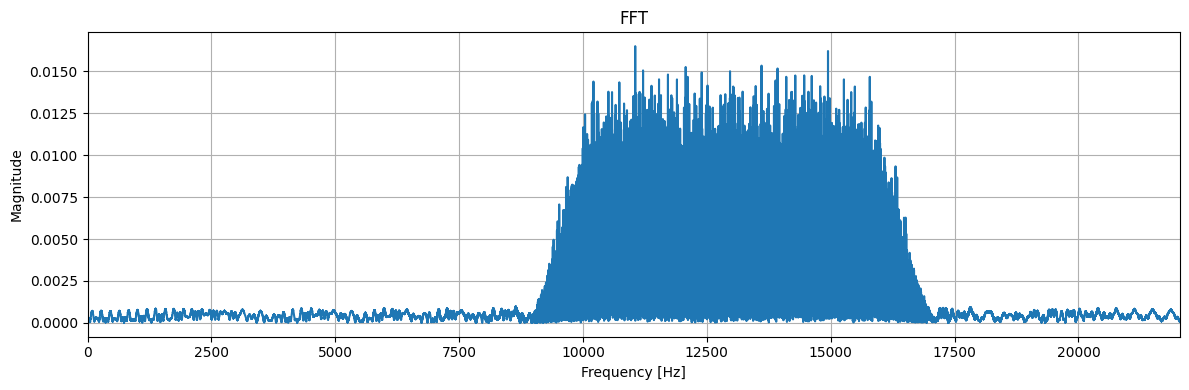

In [60]:
plot_fft(rx_audio,fs)

(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'FFT'}, xlabel='Frequency [Hz]', ylabel='Magnitude'>)

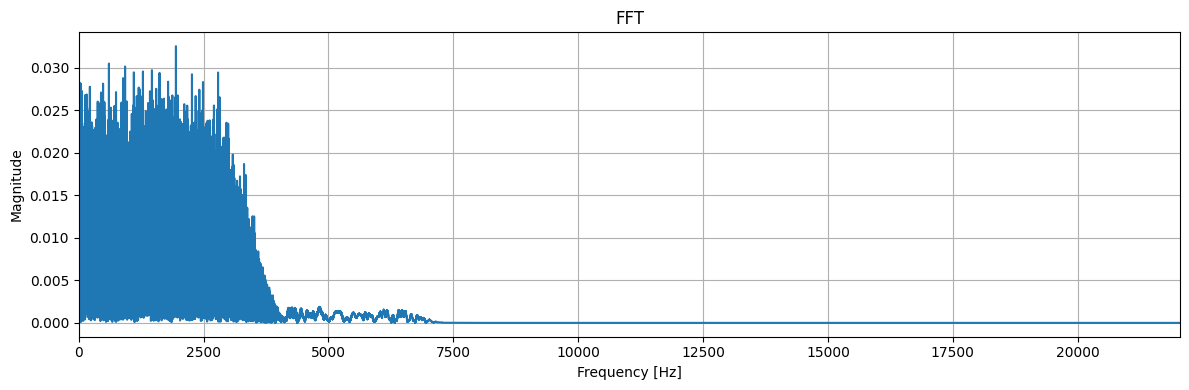

In [61]:
plot_fft(rx_baseband,fs)

In [62]:
#plot_complex_parts(rx_audio)

In [63]:
reference_zc = generate_zadoff_chu_audio(ZC_LENGTH, ZC_ROOT)
zc_start_idx, corr = matched_filter_sync(rx_baseband, reference_zc)

pilot_start_idx = locate_pilot_start(
    sync_start_idx=zc_start_idx,
    sync_length=ZC_LENGTH,
    fs=FS,
    gap_seconds=SYNC_GAP_SECONDS,
)

print('-' * 50)
print(f'Zadoff-Chu peak found at sample index: {zc_start_idx}')
print(f'Zadoff-Chu peak time: {zc_start_idx / FS:.6f} s')
print(f'Expected ZC start for repaired TX: {int(5.0 * FS)}')
print(f'Correlation peak / median: {corr[zc_start_idx] / (np.median(corr) + 1e-12):.3e}')
print(f'Sync length samples: {ZC_LENGTH}')
print(f'Sync gap samples: {int(FS * SYNC_GAP_SECONDS)}')
print(f'Known pilots begin at sample index: {pilot_start_idx}')
print(f'Expected pilot waveform start for repaired TX: {int(5.0 * FS) + ZC_LENGTH}')
print('-' * 50)


--------------------------------------------------
Zadoff-Chu peak found at sample index: 220500
Zadoff-Chu peak time: 5.000000 s
Expected ZC start for repaired TX: 220500
Correlation peak / median: 2.589e+14
Sync length samples: 839
Sync gap samples: 0
Known pilots begin at sample index: 221339
Expected pilot waveform start for repaired TX: 221339
--------------------------------------------------


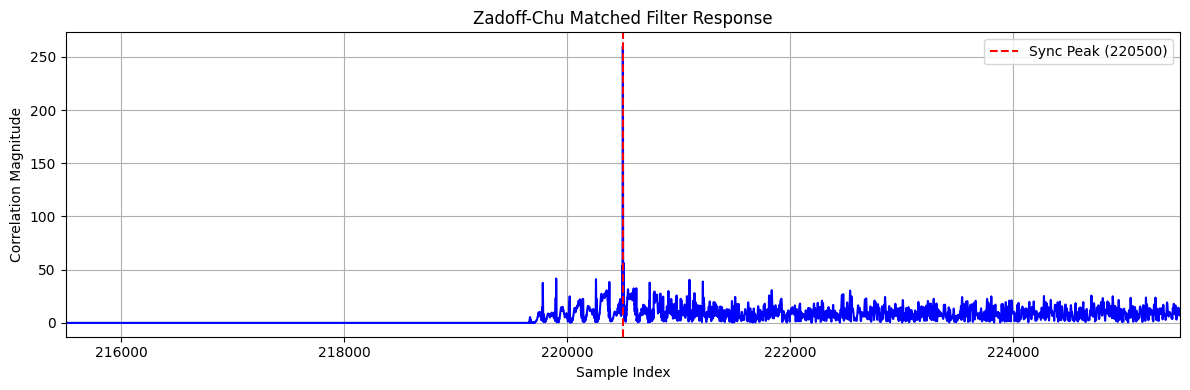

In [64]:
plot_correlation_response(corr, zc_start_idx)
plt.show()


# Pilot Extraction


In [65]:
pilot_bits = config.pilot_bits
pilot_symbols = map_bits_to_symbols(pilot_bits, config.M, METHOD=config.modulation_method)
KNOWN_PILOT_SYMBOLS = pilot_symbols

rx_pilots = slice_pilot_samples(
    rx_baseband=rx_baseband,
    pilot_start_idx=pilot_start_idx,
    num_pilot_symbols=len(KNOWN_PILOT_SYMBOLS),
    samples_per_symbol=SAMPLES_PER_SYMBOL,
    span_symbols=config.SPAN,
)

print(f'Pilot bits: {len(pilot_bits)}')
print(f'Pilot symbols: {len(KNOWN_PILOT_SYMBOLS)}')
print(f'Samples/symbol: {SAMPLES_PER_SYMBOL}')
print(f'SINC span symbols from config: {config.SPAN}')
print(f'SINC leading delay samples: {config.SPAN * SAMPLES_PER_SYMBOL}')
print(f'Pilot slice samples: {len(rx_pilots)}')
print(f'Expected pilot slice samples: {(len(KNOWN_PILOT_SYMBOLS) + config.SPAN) * SAMPLES_PER_SYMBOL}')


Pilot bits: 32
Pilot symbols: 32
Samples/symbol: 7
SINC span symbols from config: 4
SINC leading delay samples: 28
Pilot slice samples: 252
Expected pilot slice samples: 252


(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Real Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>,
        <Axes: title={'center': 'Imaginary Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>],
       dtype=object))

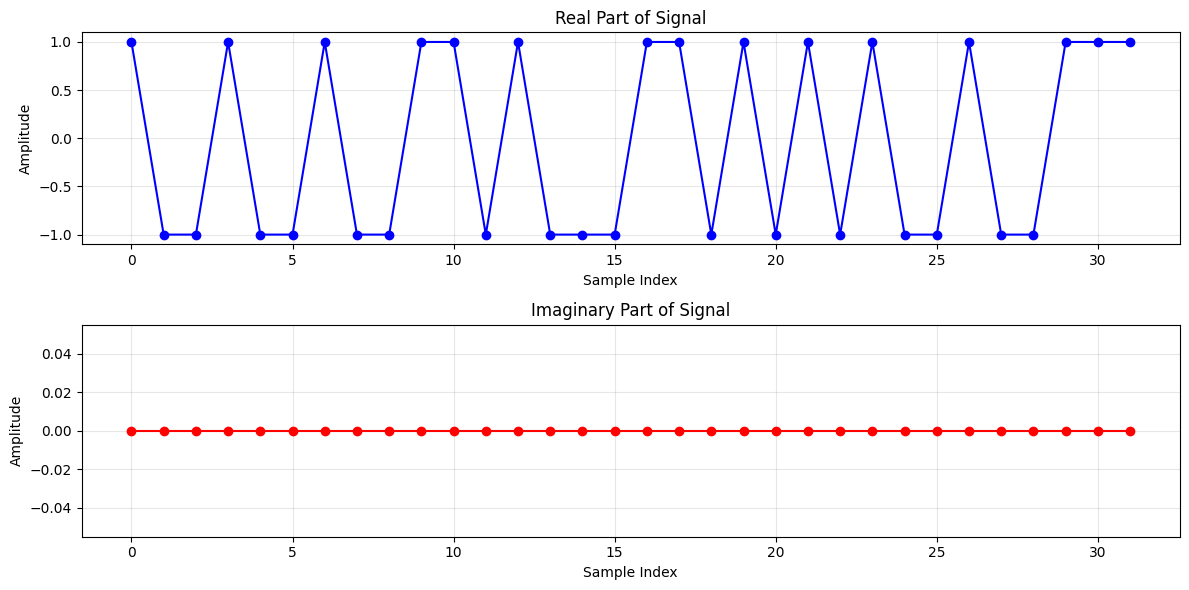

In [66]:
plot_complex_parts(pilot_symbols)

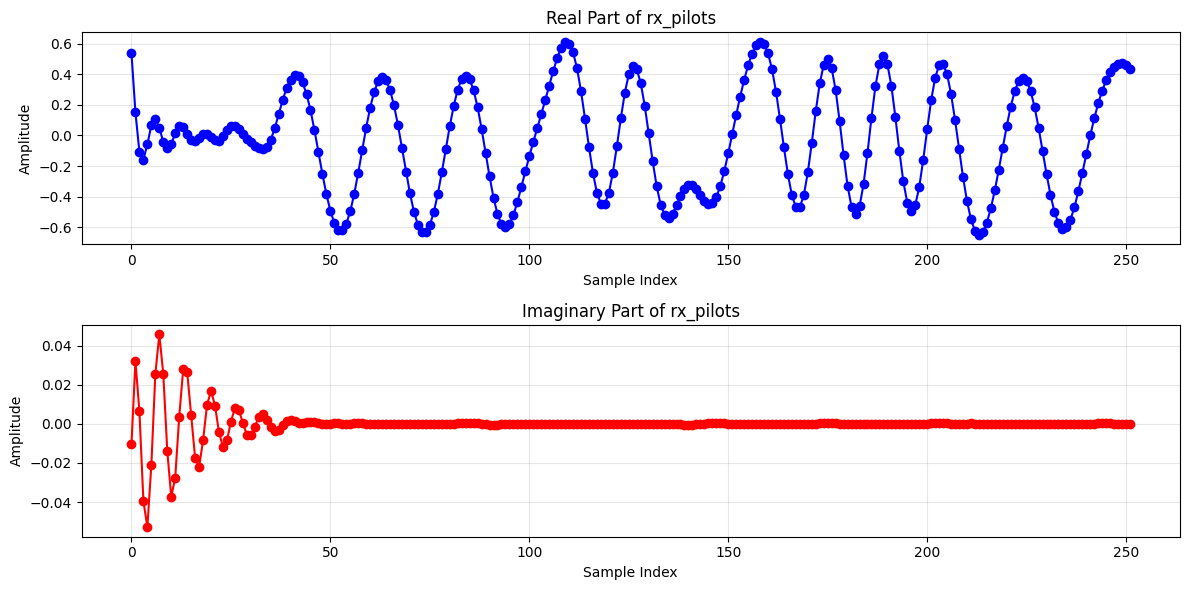

In [67]:
plot_complex_parts(rx_pilots, title_prefix='rx_pilots')
plt.show()

### Synchronization 

Offset metrics for offsets 0..6: [0.7673473288956586, 2.160378139182132, 3.666535715453872, 5.048127405813362, 6.030736768405132, 6.349666910855567, 5.8038785329277385]
Best offset inside pilot slice: 5
Best pilot timing metric: 6.349667
First pilot decision sample index: 221372
First message decision sample index: 221596


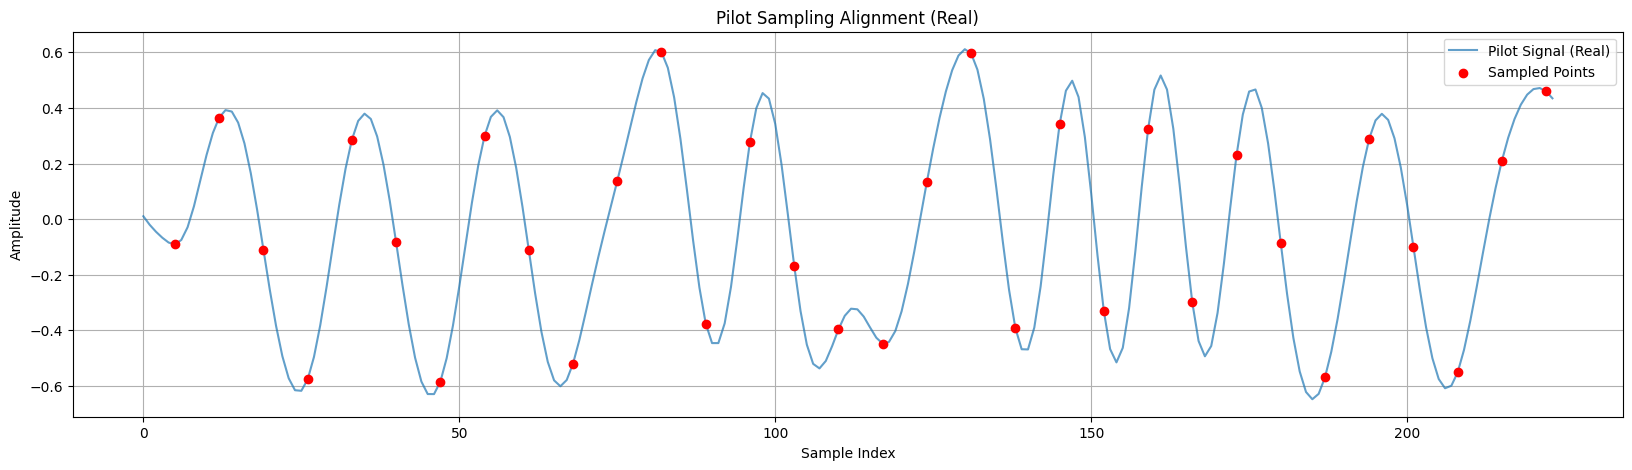

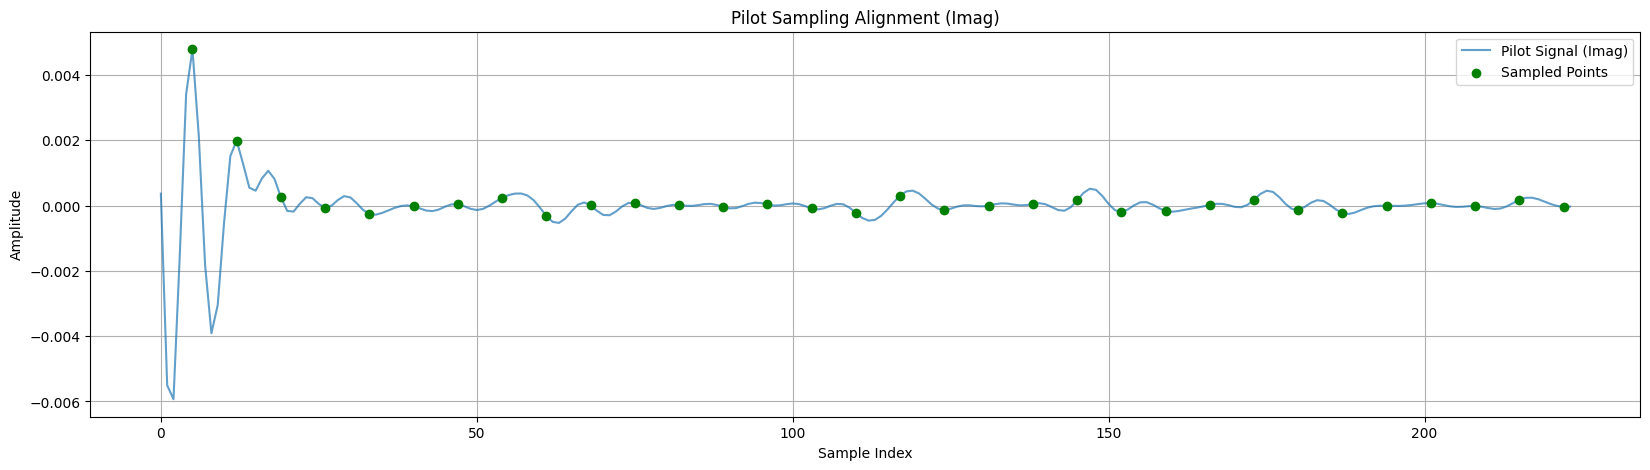


Known pilot symbols:
[ 1.+0.j -1.+0.j -1.+0.j  1.+0.j -1.+0.j -1.+0.j  1.+0.j -1.+0.j -1.+0.j
  1.+0.j  1.+0.j -1.+0.j  1.+0.j -1.+0.j -1.+0.j -1.+0.j  1.+0.j  1.+0.j
 -1.+0.j  1.+0.j -1.+0.j  1.+0.j -1.+0.j  1.+0.j -1.+0.j -1.+0.j  1.+0.j
 -1.+0.j -1.+0.j  1.+0.j  1.+0.j  1.+0.j]

Recovered pilot samples:
[-0.0906325 +4.78954964e-03j  0.3655388 +1.98828292e-03j
 -0.10925894+2.51384956e-04j -0.57668531-6.70197029e-05j
  0.2855516 -2.57932038e-04j -0.0831805 -2.29708679e-05j
 -0.58495531+4.14235843e-05j  0.29961243+2.36770235e-04j
 -0.11160974-3.15078880e-04j -0.51946513+9.79324004e-06j
  0.13764631+8.32307401e-05j  0.6009388 +1.80248916e-05j
 -0.37543426-4.23669982e-05j  0.27839091+3.37164286e-05j
 -0.16722595-8.90220404e-05j -0.39676644-2.26029362e-04j
 -0.44767904+3.06899015e-04j  0.13443921-1.31420342e-04j
  0.59631214-1.38243450e-07j -0.39131443+5.22714621e-05j
  0.34067971+1.58600873e-04j -0.32993512-1.96451329e-04j
  0.32263472-1.63835573e-04j -0.29910284+2.01506675e-05j
  0.229

In [68]:
L = SAMPLES_PER_SYMBOL
KNOWN = KNOWN_PILOT_SYMBOLS

# ================================
# REMOVE SINC DELAY REGION
# ================================
rxp = rx_pilots[config.SPAN * L:]

NUM_PILOTS = len(KNOWN)

# ================================
# FIND BEST OFFSET
# ================================
best_offset = 0
best_metric = -np.inf
offset_metrics = []

for offset in range(L):
    samples = rxp[offset::L][:NUM_PILOTS]
    
    metric = np.abs(np.sum(samples * np.conj(KNOWN)))
    offset_metrics.append(metric)
    
    if metric > best_metric:
        best_metric = metric
        best_offset = offset

print(f"Offset metrics for offsets 0..{L - 1}: {[float(m) for m in offset_metrics]}")
print(f"Best offset inside pilot slice: {best_offset}")
print(f"Best pilot timing metric: {best_metric:.6f}")
print(f"First pilot decision sample index: {pilot_start_idx + config.SPAN * L + best_offset}")
print(f"First message decision sample index: {pilot_start_idx + config.SPAN * L + best_offset + NUM_PILOTS * L}")

# ================================
# GET FINAL SAMPLE INDICES
# ================================
sample_indices = np.arange(best_offset, best_offset + NUM_PILOTS*L, L)

# ================================
# PLOT REAL PART
# ================================
import matplotlib.pyplot as plt

plt.figure(figsize=(20,5))

plt.plot(np.real(rxp), label="Pilot Signal (Real)", alpha=0.7)

plt.scatter(sample_indices,
            np.real(rxp[sample_indices]),
            color='red',
            label="Sampled Points",
            zorder=5)

plt.title("Pilot Sampling Alignment (Real)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()

# ================================
# PLOT IMAG PART
# ================================
plt.figure(figsize=(20,5))

plt.plot(np.imag(rxp), label="Pilot Signal (Imag)", alpha=0.7)

plt.scatter(sample_indices,
            np.imag(rxp[sample_indices]),
            color='green',
            label="Sampled Points",
            zorder=5)

plt.title("Pilot Sampling Alignment (Imag)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()

# ================================
# VERIFY SYMBOLS
# ================================
rx_samples = rxp[best_offset::L][:NUM_PILOTS]
pilot_channel = np.vdot(KNOWN, rx_samples) / np.vdot(KNOWN, KNOWN)
rx_samples_equalized = rx_samples / pilot_channel
recovered_pilot_bits = symbols_to_bits(rx_samples_equalized, M=config.M, METHOD=config.modulation_method)
pilot_bit_errors = np.sum(recovered_pilot_bits[:len(pilot_bits)] != pilot_bits)

print("\nKnown pilot symbols:")
print(KNOWN)

print("\nRecovered pilot samples:")
print(rx_samples)

print("\nEstimated pilot channel scalar:")
print(pilot_channel)
print(f"abs={np.abs(pilot_channel):.6f}, phase_rad={np.angle(pilot_channel):.6f}")

print("\nEqualized recovered pilot samples:")
print(rx_samples_equalized)
print(f"Pilot bit errors after equalizing pilots: {pilot_bit_errors} / {len(pilot_bits)}")

In [69]:
start = pilot_start_idx + config.SPAN * L + best_offset

downsampled_symbols, ds_signal = downsample_from_offset(
    rx_baseband,
    start,
    L
)

NUM_PILOT_SYMBOLS = len(KNOWN_PILOT_SYMBOLS)
NUM_MESSAGE_SYMBOLS = config.total_symbols
message_symbol_start = NUM_PILOT_SYMBOLS
message_symbol_stop = message_symbol_start + int(NUM_MESSAGE_SYMBOLS * 7 / 4)

print(f'Downsample start index: {start}')
print(f'First downsampled symbol is pilot symbol 0')
print(f'Pilot symbols to skip before message: {NUM_PILOT_SYMBOLS}')
print(f'Pilot bits to skip before message: {len(pilot_bits)}')
print(f'Message symbol range in downsampled array: [{message_symbol_start}, {message_symbol_stop})')
print(f'First message sample index: {start + NUM_PILOT_SYMBOLS * L}')
print(f'Downsampled symbols available: {len(downsampled_symbols)}')

Downsample start index: 221372
First downsampled symbol is pilot symbol 0
Pilot symbols to skip before message: 32
Pilot bits to skip before message: 32
Message symbol range in downsampled array: [32, 87532)
First message sample index: 221596
Downsampled symbols available: 47508


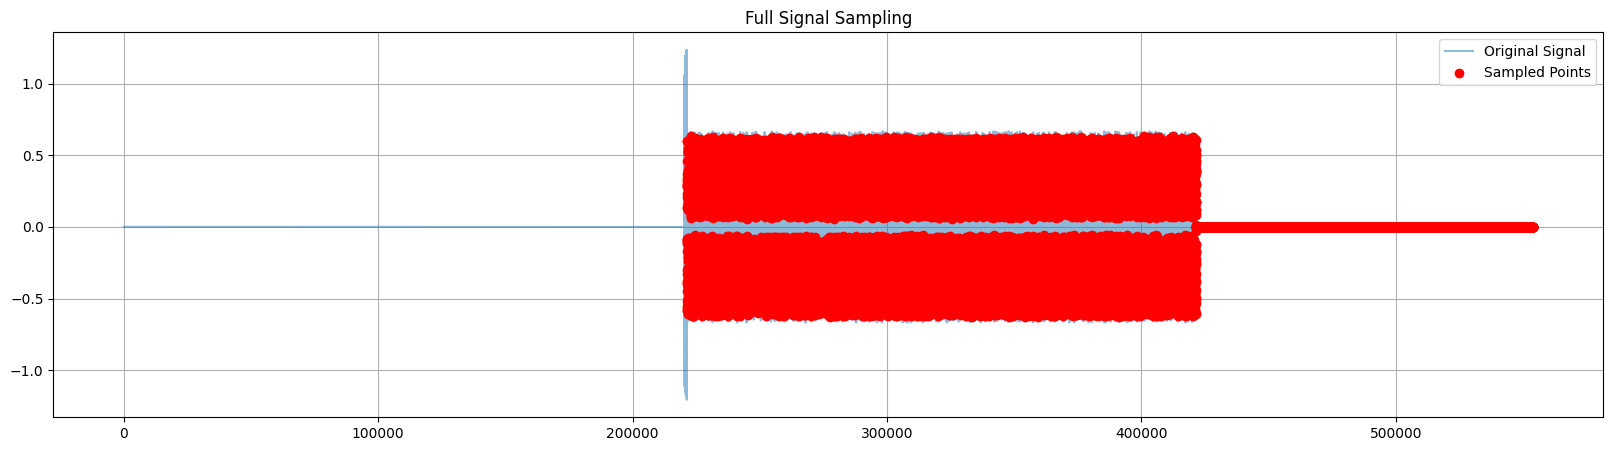

In [70]:
plt.figure(figsize=(20,5))

plt.plot(np.real(rx_baseband), label="Original Signal", alpha=0.5)

sample_indices = np.arange(start, len(rx_baseband), L)

plt.scatter(sample_indices,
            np.real(rx_baseband[sample_indices]),
            color='red',
            label="Sampled Points",
            zorder=5)

plt.title("Full Signal Sampling")
plt.grid(True)
plt.legend()
plt.show()

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Real Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>,
        <Axes: title={'center': 'Imaginary Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>],
       dtype=object))

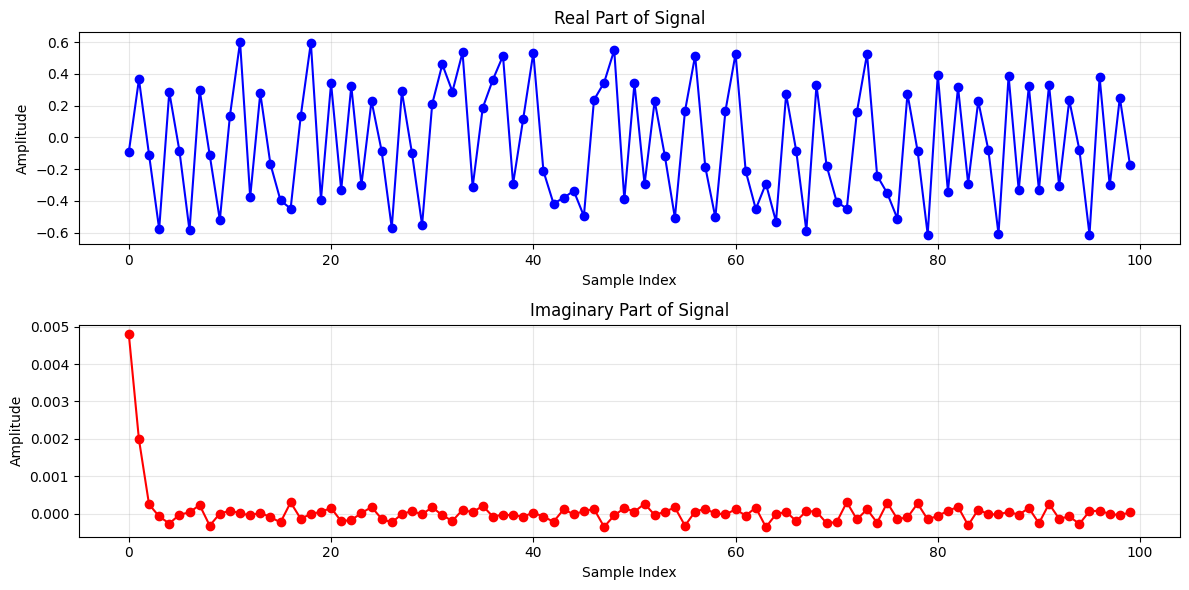

In [71]:
plot_complex_parts(rx_baseband[sample_indices][0:100])

In [72]:
pilot_symbol_count = len(KNOWN_PILOT_SYMBOLS)
message_symbols = downsampled_symbols[pilot_symbol_count : pilot_symbol_count + int(config.total_symbols * 7 / 4)]

# Apply the equalization scalar to the downsampled and message symbols
downsampled_symbols_equalized = downsampled_symbols / pilot_channel
message_symbols_equalized = message_symbols / pilot_channel

recovered_bits_with_pilots = symbols_to_bits(
    downsampled_symbols_equalized,  # <-- Use equalized symbols here
    M=config.M,
    METHOD=config.modulation_method
)

recovered_bits = symbols_to_bits(
    message_symbols_equalized,      # <-- Use equalized symbols here
    M=config.M,
    METHOD=config.modulation_method
)
print(len(recovered_bits))


47476


In [73]:
if config.Error_correction=="HAMM":
    recovered_bits = hamming74_decode(recovered_bits)
elif config.Error_correction=="LDPC":
    recovered_bits = ldpc_decode(recovered_bits)

In [74]:
print(len(recovered_bits))

print(f'Demodulated symbols including pilots: {len(downsampled_symbols)}')
print(f'Message symbols used for BER: {len(message_symbols)}')
print(f'Skipped pilot symbols before BER: {pilot_symbol_count}')
print(f'Skipped pilot bits before BER: {len(pilot_bits)}')

27128
Demodulated symbols including pilots: 47508
Message symbols used for BER: 47476
Skipped pilot symbols before BER: 32
Skipped pilot bits before BER: 32


In [75]:
input_path = "../data/message.txt"
with open(input_path, "r") as f:
        data_binary = f.read().strip()


# Calculate Bit Error Rate (BER)
recovered_bit_string_with_pilots = ''.join(map(str, recovered_bits_with_pilots))
recovered_bit_string = ''.join(map(str, recovered_bits))

# This is the old alignment, kept only as a diagnostic. It should be bad for the repaired frame.
wrong_min_length = min(len(recovered_bit_string_with_pilots), len(data_binary))
wrong_bit_errors = sum(
    r != d
    for r, d in zip(recovered_bit_string_with_pilots[:wrong_min_length], data_binary[:wrong_min_length])
)
wrong_ber = wrong_bit_errors / wrong_min_length if wrong_min_length > 0 else 0

# Determine the length to compare (use the shorter length or match as needed)
min_length = min(len(recovered_bit_string), len(data_binary))

# Compare bits
bit_errors = sum(r != d for r, d in zip(recovered_bit_string[:min_length], data_binary[:min_length]))

# Calculate BER
ber = bit_errors / min_length if min_length > 0 else 0

print(f"Recovered bits: {recovered_bit_string[:min_length]}")
print(f"Original bits:  {data_binary[:min_length]}")
print(f"\nTotal bits compared: {min_length}")
print(f"Bit errors: {bit_errors}")
print(f"Bit Error Rate (BER): {ber:.6f} ({ber*100:.2f}%)")

Recovered bits: ...
Original bits:  ...

Total bits compared: 27128
Bit errors: 13541
Bit Error Rate (BER): 0.499152 (49.92%)


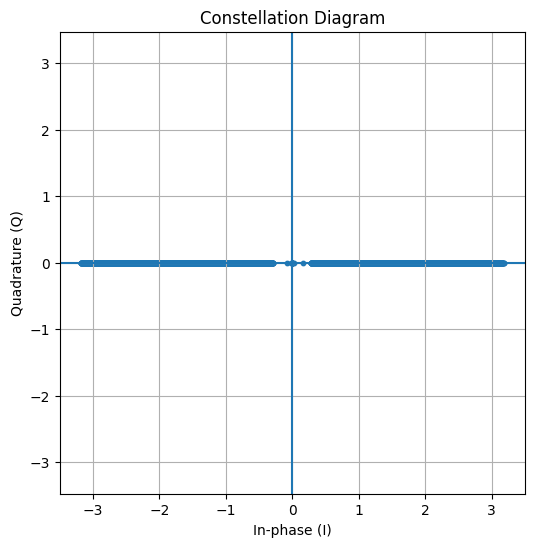

In [76]:
plt.figure(figsize=(6,6))

no_of_symbols_to_plot = 500
plot_symbols = message_symbols_equalized[: -1]
plt.scatter(np.real(plot_symbols),
            np.imag(plot_symbols),
            s=10)

plt.axhline(0)
plt.axvline(0)

plt.title("Constellation Diagram")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.grid(True)
plt.axis('equal')

plt.show()